# Sampling and Bootstrap Distributions of Parameters

Now that we understand how moments are used to parameterize distributions, we can discuss different types of distributions that come up in working with random data and parameter estimates. In particular, we have introduced the general idea of the bootstrap distribution in {doc}`Section 5.6<bootstrap-dist-confidence-intervals.ipynb>` but at that time did not have the mathematical tools that we use for characterizing the distributions of random variables that we have available to us at this point in this book. 

## Sampling Distribution of an Estimator

Consider a scenario in which we have independent random variables $\mathbf{X} = \left[ X_0, X_1, \ldots, X_{n-1}\right]$ from a  distribution that is characterized by some parameter $\theta$. Let $\hat{\Theta}$ be an estimator for $\theta$; that is $\hat{\Theta}$ is some function $\hat{\Theta} = g(\mathbf{X})$, where $g()$ is chosen to make $\hat{\Theta}$ be a "good" (e.g. unbiased, low MSE) estimator for $\theta$. Then $\hat{\Theta}$ is itself a random variable and hence has some distribution that is generally different than the distribution of the $X_i$. The distribution of $\hat{\Theta}$ is called the *sampling distribution*:


````{card}
DEFINITION
^^^
```{glossary}
sampling distribution
    Given a vector of independent random variables $\mathbf{X}$ and a parameter estimator $\hat{\Theta}=g(\mathbf{X})$, the *sampling distribution* is the probability distribution of $\hat{\Theta}$.
```
````

This will be made much more clear with an example. Suppose we have 25 random values from some random distribution and we want to estimate the sampling distribution for the mean estimator. The function below takes as input a SciPy distribution object, creates $2^{16}$ values of the sample mean for samples of length 25, and then displays a normalized histogram of the data, which is an empirical density for the mean estimator.

In [1]:
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np
import numpy.random as npr


from matplotlib import animation
from matplotlib.animation import PillowWriter
from IPython.display import HTML


def sampling_dist(dist_obj, sample_length=25, samples=2**16):
  np.random.seed(45673376) # arbitray but want results to be consistent
  num_means = 2**16

  xvals = dist_obj.rvs(size=(num_means, sample_length))
  means=xvals.mean(axis=1)

  fig = plt.figure()
  fig.set_dpi(100)
  fig.set_size_inches(5, 4)




  ax = plt.axes(xlim=(np.min(means), np.max(means)), ylim=(0, 1))
  #plt.grid(axis='y')


  def animate(i):
    plt.clf()
    num=2*2**(i+1)

    if num <= 64:
      mybins=np.linspace(np.min(means), np.max(means), 10)
    elif num <= 1024:
      mybins=np.linspace(np.min(means), np.max(means), 20)
    else:
      mybins=np.linspace(np.min(means), np.max(means), 50)


    plt.hist(means[:num], bins=mybins, density=True);
    plt.title(f'# of means = {num}');

    return []



  anim = animation.FuncAnimation(fig, animate, 
                                 frames=int(np.log2(num_means/4))+1,
                                 interval=15,
                                 blit=False, repeat=False)

  #Comment this out and uncomment the anim.save() to write the GIF
  out = anim.to_jshtml(fps=2) 
  plt.close()
  #print(np.min(means), np.max(means))
  return HTML(out)

Let's start by applying this function to a uniform random variable on $[0,10]$.

In [2]:
U= stats.uniform(0,10)
sampling_dist(U)

Here is the result for the exponential random variable with mean 5:

In [3]:
E=stats.expon(scale=5)
sampling_dist(E)

And here are the results for a chi-squared random variable with 6 degrees of freedom:

In [4]:
E=stats.chi2(df=6)
sampling_dist(E)

Let's try a discrete distribution. Here is the sampling distribution for the mean of a binomial random variable with 20 trials and probability of success 0.2:

In [5]:
B = stats.binom(100, 0.2)
sampling_dist(B)

Even the sampling distribution for the mean of this Binomial random variable looks almost Normal (although it does have some "spikes" in the distribution that come from its discrete nature).

By the Central Limit Theorem, the average of a sequence of almost any time of independent random variables converges to the Normal distribution as the number of random variables being averaged goes to infinity. These results suggest that the sampling distribution of the mean is approximately Normal even if tens of random variables are averaged together. The sampling distribution will not be well approximated by the Normal for most distributions if the number of random variables being averaged is small. For instance, the average of two uniform random variables has a triangle-shaped density:

In [6]:
U= stats.uniform(0,10)
sampling_dist(U, sample_length=2)

One special case is if the data comes from a Normal distribution. Since a linear combination of independent Normal random variables is Normal, the sampling distribution for data from a Normal distribution is always Normal. See the example below for samples of size 2 from a Normal(3, 2) distribution:

In [7]:
N= stats.norm(3, 2)
sampling_dist(N, sample_length=2)

As the number of samples of the estimator goes to infinity, the empirical distribution of the estimator will converge to the true sampling distribution.  Thus, we can consider the sampling distribution to be generated **drawing sample from the original distribution**.

## Bootstrap Distribution of an Estimator

Next we consider the boostrap distribution of an estimator.  For a given parameter, we can create bootstrap samples from observed data by resampling with replacement and then computing the parameter from the bootstrap samples, as we did to create confidence intervals in  {doc}`Section 9.5<confidence-intervals-estimates>`. Since the bootstrapped value of the parameter will depend on the bootstrap sample, which is randomly chosen, the boostrap sample will be a random variable and thus its distribution can be characterized. Before we illustrate this with an example, let's consider some observations about the bootstrap distribution:

1. The bootstrap distribution is inherently a discrete distribution. If there are $n$ values in the original sample, then the number of ways to create a bootstrap sample is $n^n$. Note, however, that the number of possible values grows quickly with the number of values in the original sample. For instance, if there were $25$ values in the original sample, then the number of possible values of the parameter estimator is as high as 

In [8]:
25 ** 25

88817841970012523233890533447265625

2. The minimum and maximum values of a bootstrap distribution are always finite. For instance, if the mean estimator is used, then the minimum possible value will occur when every value in the bootstrap sample is equal to the minimum value in the original data sample. Thus, the minimum possible value of the mean estimator is equal to the minimum value in the original data sample, and we can make a similar conclusion for the maximum.

An implication of both these observations is that if the data comes from a continuous distribution, the bootstrap distribution will never converge to the sampling distribution as the number of bootstrap samples goes to infinity.

Even with these limitations, the bootstrap distribution is usually used as an approximation of the sampling distribution. However, the bootstrap distribution is usually only a good approximation of the sampling distribution if the sample size is sufficiently large (at least 10s of data points in the sample). 

Below is an example showing a random sample of data from a Normal($\mu=3,~ \sigma=2)$ distribution. Below the data are plots that show 8 different bootstrap samples from the data, along with the computed average for each bootstrap sample. 

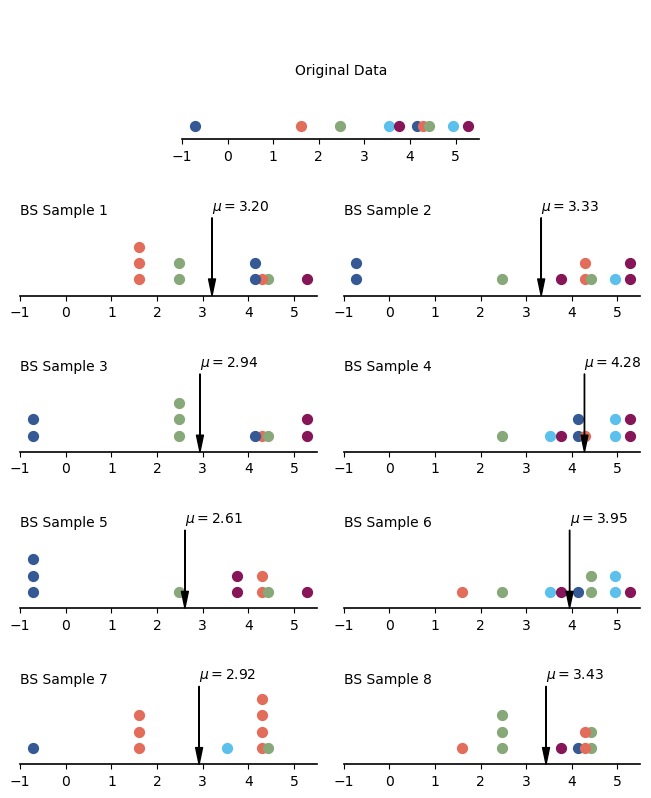

In [9]:
import matplotlib.gridspec as gridspec
gs = gridspec.GridSpec(5, 4)
#gs.update(wspace=0.5)

fig = plt.figure()
fig.set_dpi(100)
fig.set_size_inches(8, 10)
np.random.seed(23341)
N=stats.norm(3,2)
nvals = N.rvs(10)
nvals.sort()
#plt.scatter(nvals, 0.01 *np.ones(10), s=50)
ax1 = plt.subplot(gs[0, 1:3])
for i, val in enumerate(nvals):
  ax1.scatter(val, 0.01 , s=50, c='C'+str(i))
ax1.set_ylim(0, 0.1)
ax1.set_xlim(-1, 5.5)
np.random.seed(1234512)



#ax = plt.gca()
ax1.spines['left'].set_visible(False)
ax1.get_yaxis().set_visible(False)
ax1.text(2.5, 0.05, 'Original Data',horizontalalignment='center',)

#ax1 = plt.subplot(gs[0, :2], )
#ax3 = plt.subplot(gs[1, 1:3])


for sample in range(1,9):
  #bs = npr.choice(nvals, len(nvals))
  bs = npr.choice(np.arange(0,len(nvals)), len(nvals))
  bsvals = nvals[bs]
  counts={}
  for val in bs: 
    counts[val]=0
  xstart = 2*((sample+1) %2)
  ax = plt.subplot(gs[(sample+1) // 2, xstart:xstart+2])


  for val in bs:
    counts[val]+=1
    ax.scatter(nvals[val], 0.005*counts[val], s=50, c = 'C'+str(val))
    
  height = 0.01*(max(counts.values())+1)
  avg = bsvals.mean()
  #ax.scatter(avg, 0.005, marker='x')
  #ax.arrow(avg, height-0.01, 0, -height+0.01+0.005, head_width = 0.15, head_length=0.005 )
  ax.annotate(f'$\mu=${avg:0.2f}', xy=(avg, 0),  xycoords = 'data',
              xytext = (avg, 0.03),
              arrowprops=dict(facecolor='black', width=0.2, headwidth=5),
              horizontalalignment='left', verticalalignment='top',
  )
  ax.text(-1, 0.025, 'BS Sample '+str(sample),horizontalalignment='left',)
  
  ax.set_ylim(0, 0.04)
  ax.set_xlim(-1, 5.5)

  ax.spines['left'].set_visible(False)
  ax.get_yaxis().set_visible(False)

If we repeat the bootstrap process many times and compute the histogram of the data, we will get an empirical **bootstrap distribution** for this data sample. The function below plots the empirical histogram of the bootstrap distribution as a function of the number of bootstrap samples varies from 100 to 1 million, along with the sampling distribution for the mean estimator (the solid curve). 

In [12]:
def bootstrap_vs_sampling(num_data_samples = 10,
                         num_bs_samples = 1_000_000, seed=23341):


  np.random.seed(seed)
  N=stats.norm(3,2)
  nvals = N.rvs(num_data_samples)

  avgs = np.zeros(num_bs_samples)


  for sample in range(num_bs_samples):
    bs = npr.choice(nvals, len(nvals))
    avg =bs.mean()
    avgs[sample] = avg

  fig = plt.figure()
  fig.set_dpi(100)
  fig.set_size_inches(8, 10)
  gs = gridspec.GridSpec(5,1)



  # Set up sampling distribution for mean estimator
  mu_hat = stats.norm(3, 2/np.sqrt(num_data_samples))
  x = np.linspace(1.5, 5)

  for i in range(5):
    ax = plt.subplot(gs[i,0])

    ax.hist(avgs[:10**(i+2)], density=True, bins=10*(i+1), label='BS Dist')
    ax.plot(x, mu_hat.pdf(x) , label = 'Sampling Dist')
    ax.legend()         

    ax.set_xlim(1.5, 6)

Here are the results where there are 10 values in the original data sample:

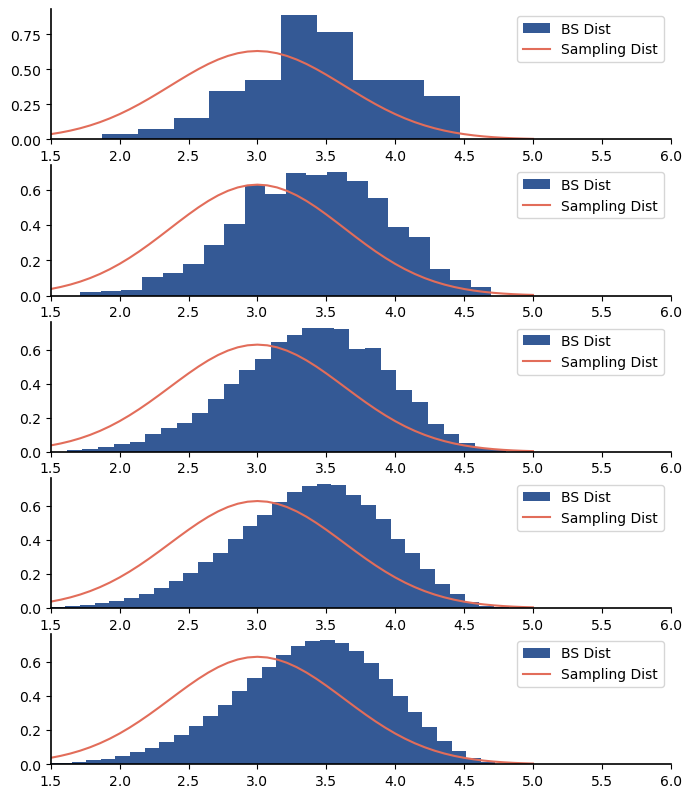

In [13]:
bootstrap_vs_sampling()

As the number of bootstrap samples increases, the bootstrap distribution looks more like a Normal distribution, although it still has a significant skew to the right, even with 1 million samples. More importantly, the bootstrap distribution for the mean estimator differs significantly from the sampling distribution for the mean estimator, both in terms of the location of the mode of the distribution but also in terms of the spread of the distribution. That is because the original data sample is small (10 samples), and the bootstrap distribution is limited to resampling from these 10 samples.

The results below show the same experiment with 100 samples from the original distribution:

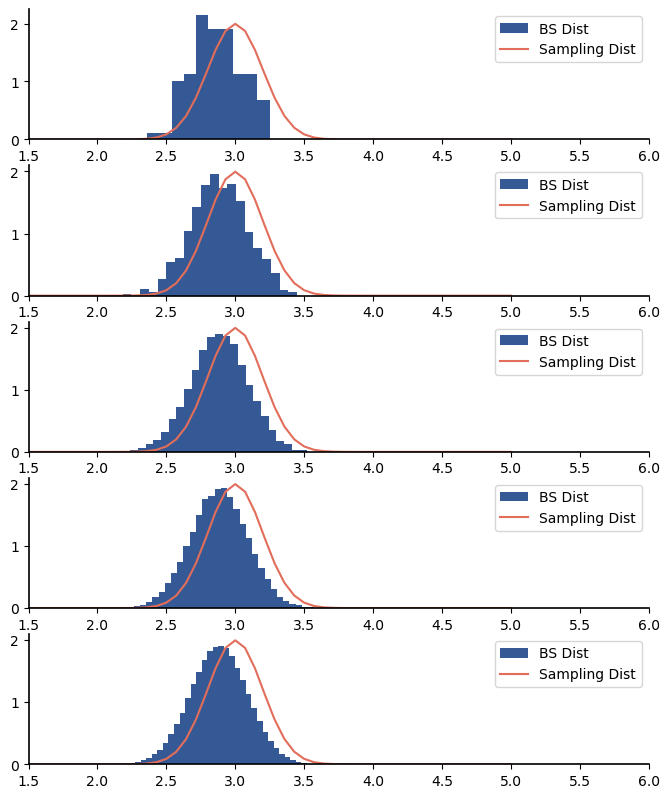

In [14]:
bootstrap_vs_sampling(num_data_samples = 100)

Although the bootstrap and sampling distributions still differ, the shape of the two distributions are now almost identical. There is just a small offset in the location of the modes/means of the distributions, and this is to be expected from the limited size of the data. These results suggest that the bootstrap distribution  provides a good approximation of the sampling distribution if the number of data samples is at least 100, and that it is a poor approximation if the number of data samples is small (less than 20).

## Terminology Review

In [18]:
from jupytercards import display_flashcards

#display_flashcards('flashcards/'+'parameter-distributions.json')

github='https://raw.githubusercontent.com/jmshea/Foundations-of-Data-Science-with-Python/main/'
github+='09-moments/flashcards/'
display_flashcards(github+'parameter-distributions.json')